# 1. Problema de Segmentare

Segmentarea tumorilor din imagini ecografice de sân (dataset BUSI) folosind arhitecturi U-Net și U-Net++.

In [5]:
# !pip uninstall -y numpy pandas scikit-learn bottleneck
# !pip install numpy==1.26.4 pandas scikit-learn bottleneck --force-reinstall

Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: Bottleneck 1.3.7
Uninstalling Bottleneck-1.3.7:
  Successfully uninstalled Bottleneck-1.3.7
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached nu

In [106]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split

SEED = 42
IMG_SIZE = 128
BATCH_SIZE = 16
NUM_EPOCHS = 25
LR = 0.0003
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Device: {DEVICE}")


Device: cpu


## 1.1 Pipeline-ul de procesare

### Încărcarea datelor BUSI (imagini + măști)

In [107]:
# Îincarcare perechi (imagine, masca) din Dataset_BUSI_with_GT

DATA_ROOT = "/Users/mutumihaela/Downloads/Dataset_BUSI_with_GT"

CLASE = ["benign", "malignant", "normal"]

imagini = []   # cai catre imagini
masti   = []   # cai catre măști
etichete = []  # 0=benign, 1=malignant, 2=normal

for cls_idx, cls_name in enumerate(CLASE):
    cls_dir = os.path.join(DATA_ROOT, cls_name)
    # Gasim toate fisierele imagine (fara _mask în nume)
    all_files = sorted(glob.glob(os.path.join(cls_dir, "*.png")))
    img_files = [f for f in all_files if "_mask" not in os.path.basename(f)]

    for img_path in img_files:
        # Construim calea mastii principale
        base = img_path.replace(".png", "")
        mask_path = base + "_mask.png"

        if not os.path.exists(mask_path):
            # Unele imagini (normal) pot să nu aibă mască -> masca va fi generată ca zerouri
            pass

        imagini.append(img_path)
        masti.append(mask_path if os.path.exists(mask_path) else None)
        etichete.append(cls_idx)

print(f"Total perechi imagine-mască: {len(imagini)}")
print(f"Distribuție clase: { {CLASE[i]: etichete.count(i) for i in range(3)} }")


Total perechi imagine-mască: 780
Distribuție clase: {'benign': 437, 'malignant': 210, 'normal': 133}


In [ ]:
# Split 70 / 15 / 15 - stratificat pe clase (identic cu clasificarea)

# separam test (15%)
idx_all = list(range(len(imagini)))
idx_tv, idx_test = train_test_split(
    idx_all, test_size=0.15, stratify=etichete, random_state=SEED
)

# Din restul (85%) --> separam validare (17.6% din cele rămase ≈ 15% din total)
et_tv = [etichete[i] for i in idx_tv]
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.176, stratify=et_tv, random_state=SEED
)

print(f"SPLIT 70/15/15:")
print(f"  Train: {len(idx_train)}")
print(f"  Val  : {len(idx_val)}")
print(f"  Test : {len(idx_test)}")

# Verificare distribuție
print("\nDistribuție pe lot:")
for nume, idxs in [("Train", idx_train), ("Val", idx_val), ("Test", idx_test)]:
    labels = [etichete[i] for i in idxs]
    procente = [labels.count(c) / len(labels) * 100 for c in range(3)]
    print(f"  {nume:<6}: " + " | ".join(
        f"{CLASE[c]}={p:.0f}%" for c, p in enumerate(procente)
    ))


SPLIT 70/15/15:
  Train: 546
  Val  : 117
  Test : 117

Distribuție pe lot:
  Train : benign=56% | malignant=27% | normal=17%
  Val   : benign=56% | malignant=27% | normal=17%
  Test  : benign=56% | malignant=26% | normal=17%


In [109]:
# Augmentări / Transformări (Albumentations – sincronizate img+mască)

transform_train = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])

transform_val = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2(),
])


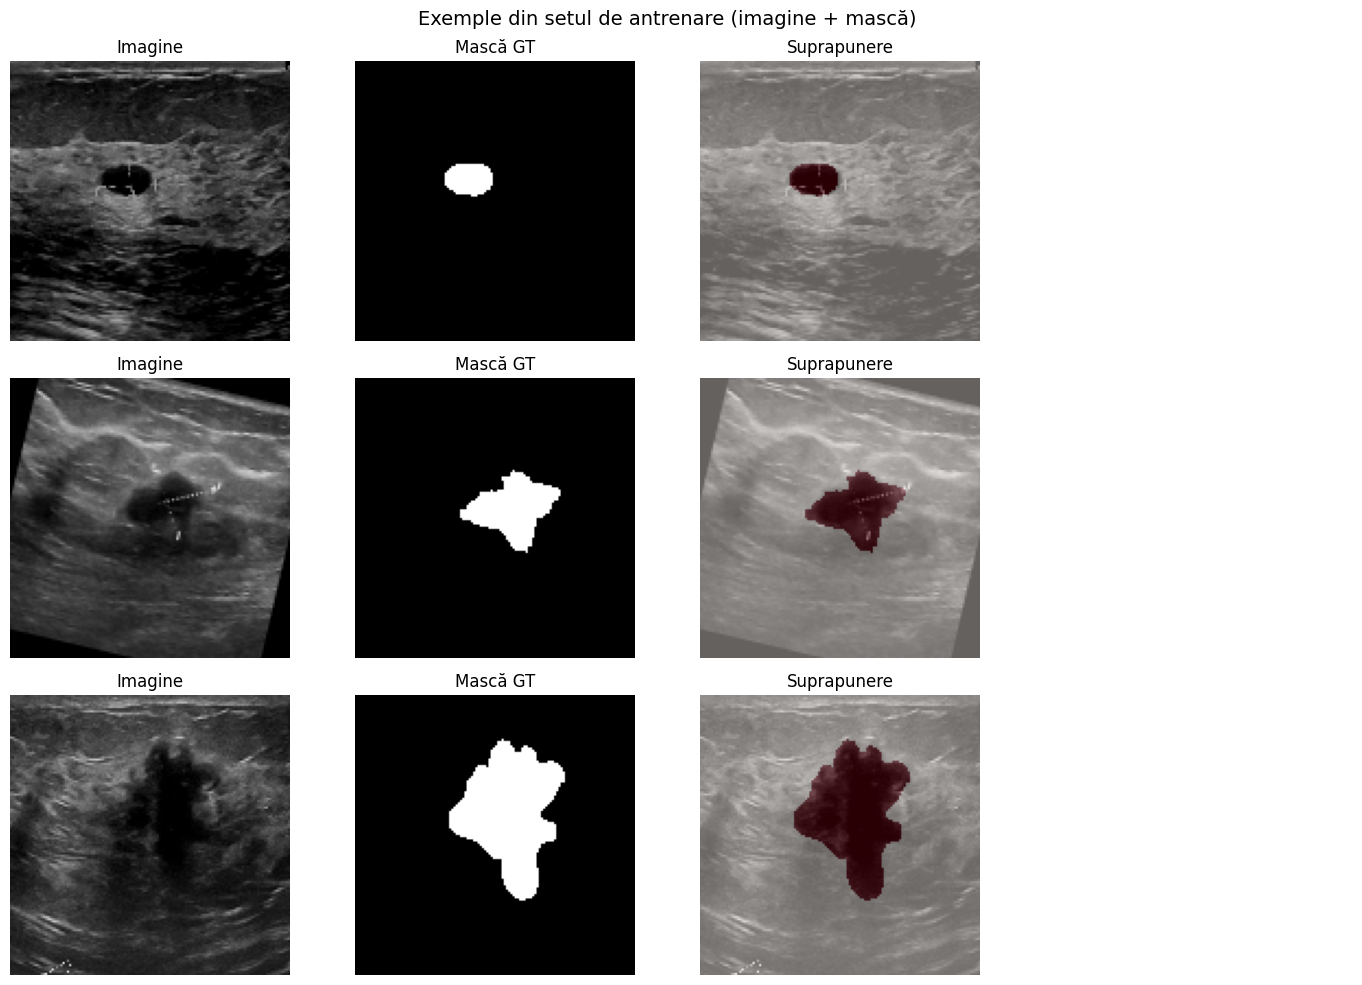

In [ ]:
# Dataset pentru segmentare (imagine + mască)

class BUSISegDataset(Dataset):
    def __init__(self, indices, imagini, masti, transform=None):
        self.indices = indices
        self.imagini = imagini
        self.masti = masti
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        # incrcare imagine RGB
        img = np.array(Image.open(self.imagini[real_idx]).convert("RGB"))

        # incrcare  masca (binar: 0 sau 1)
        mask_path = self.masti[real_idx]
        if mask_path is not None and os.path.exists(mask_path):
            mask = np.array(Image.open(mask_path).convert("L"))

            # Combinam si eventualele masti suplimentare 
            base = mask_path.replace("_mask.png", "")
            for extra in glob.glob(base + "_mask_*.png"):
                extra_mask = np.array(Image.open(extra).convert("L"))
                mask = np.maximum(mask, extra_mask)

            mask = (mask > 127).astype(np.float32)  # binarizare
        else:
            # Masca goala pentru clasa "normal"
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented["image"]
            mask = augmented["mask"]

        # Masca: [H, W] → [1, H, W]
        mask = mask.unsqueeze(0) if isinstance(mask, torch.Tensor) else torch.tensor(mask).unsqueeze(0)
        return img, mask


# Creare DataLoader-e
ds_train = BUSISegDataset(idx_train, imagini, masti, transform=transform_train)
ds_val   = BUSISegDataset(idx_val,   imagini, masti, transform=transform_val)
ds_test  = BUSISegDataset(idx_test,  imagini, masti, transform=transform_val)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Vizualizare exemple
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i in range(3):
    img, mask = ds_train[i * 10]
    img_np = img.permute(1, 2, 0).numpy() * 0.5 + 0.5  # denormalizare
    mask_np = mask.squeeze().numpy()

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("Imagine")
    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Mască GT")
    axes[i, 2].imshow(img_np)
    axes[i, 2].imshow(mask_np, alpha=0.4, cmap="Reds")
    axes[i, 2].set_title("Suprapunere")
    axes[i, 3].axis("off")

for ax in axes.flat:
    ax.axis("off")
plt.suptitle("Exemple din setul de antrenare (imagine + mască)", fontsize=14)
plt.tight_layout()
plt.show()


## 1.2 Rezultate experimentale – Problema de segmentare

### 1.2.1 Metrici de evaluare

Pentru evaluarea segmentării folosim:
- **Dice Score (F1)**: 2·|A∩B| / (|A|+|B|)
- **IoU (Jaccard)**: |A∩B| / |A∪B|
- **Pixel Accuracy**: pixeli corect clasificați / total pixeli
- **Precision**: TP / (TP + FP)
- **Recall (Sensitivity)**: TP / (TP + FN)

In [111]:

# Metrici de evaluare pentru segmentare
def compute_metrics(pred, target, threshold=0.5):
    """Calculează metrici de segmentare pe un batch."""
    pred_bin = (pred > threshold).float()
    target = target.float()

    # Flatten
    pred_flat = pred_bin.view(-1)
    tgt_flat = target.view(-1)

    tp = (pred_flat * tgt_flat).sum()
    fp = (pred_flat * (1 - tgt_flat)).sum()
    fn = ((1 - pred_flat) * tgt_flat).sum()
    tn = ((1 - pred_flat) * (1 - tgt_flat)).sum()

    # Dice
    dice = (2 * tp + 1e-8) / (2 * tp + fp + fn + 1e-8)
    # IoU
    iou = (tp + 1e-8) / (tp + fp + fn + 1e-8)
    # Pixel Accuracy
    acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    # Precision
    precision = (tp + 1e-8) / (tp + fp + 1e-8)
    # Recall
    recall = (tp + 1e-8) / (tp + fn + 1e-8)

    return {
        "dice": dice.item(),
        "iou": iou.item(),
        "accuracy": acc.item(),
        "precision": precision.item(),
        "recall": recall.item()
    }


def evaluate_model(model, dataloader, device, criterion=None):
    """Evaluare completă pe un DataLoader."""
    model.eval()
    all_metrics = {"dice": [], "iou": [], "accuracy": [], "precision": [], "recall": []}
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for imgs, masks in dataloader:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = torch.sigmoid(model(imgs))

            if criterion is not None:
                loss = criterion(preds, masks)
                total_loss += loss.item()

            m = compute_metrics(preds, masks)
            for k in all_metrics:
                all_metrics[k].append(m[k])
            n_batches += 1

    avg = {k: np.mean(v) for k, v in all_metrics.items()}
    if criterion is not None:
        avg["loss"] = total_loss / n_batches
    return avg


In [112]:
# Functie generala de antrenare

def train_model(model, dl_train, dl_val, device, num_epochs=NUM_EPOCHS, lr=LR, model_name="Model"):
    
    criterion = smp.losses.DiceLoss(mode="binary", from_logits=False)
    bce = nn.BCELoss()

    def combined_loss(pred, target):
        return criterion(pred, target) + bce(pred, target)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=5,
        factor=0.5
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": []
    }

    best_dice = 0.0
    best_state = None

    for epoch in range(num_epochs):

        # TRAIN 
        model.train()
        epoch_loss = 0.0

        for imgs, masks in dl_train:
            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = torch.sigmoid(model(imgs))

            loss = combined_loss(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(dl_train)

        # VALIDARE 
        val_metrics = evaluate_model(
            model,
            dl_val,
            device,
            criterion=combined_loss
        )

        val_loss = val_metrics["loss"]
        val_dice = val_metrics["dice"]
        val_iou = val_metrics["iou"]

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        # Salvam cel mai bun model
        if val_dice > best_dice:
            best_dice = val_dice
            best_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }

        # PRINT LA FIECARE EPOCĂ
        print(
            f"[{model_name}] "
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Dice: {val_dice:.4f} | "
            f"IoU: {val_iou:.4f} | "
            f"LR: {current_lr:.6f}"
        )

    model.load_state_dict(best_state)

    print(f"\n✓ Best {model_name} restaurat — Val Dice: {best_dice:.4f}")

    return model, history

In [113]:

# Functii de vizualizare
def plot_training_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(history["train_loss"], label="Train Loss", linewidth=2)
    ax1.plot(history["val_loss"],   label="Val Loss",   linewidth=2)
    ax1.set_xlabel("Epocă")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} – Loss")
    ax1.legend()
    ax1.grid(True)

    # Dice + IoU
    ax2.plot(history["val_dice"], label="Val Dice", linewidth=2)
    ax2.plot(history["val_iou"],  label="Val IoU",  linewidth=2)
    ax2.set_xlabel("Epocă")
    ax2.set_ylabel("Scor")
    ax2.set_title(f"{title} – Dice & IoU")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


def plot_predictions(model, dataset, device, n=5, title="Predicții"):
    model.eval()
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    cols = ["Imagine", "Mască GT", "Predicție", "Suprapunere"]
    for j, col in enumerate(cols):
        axes[0, j].set_title(col, fontsize=13, fontweight="bold")

    indices = random.sample(range(len(dataset)), n)
    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        with torch.no_grad():
            pred = torch.sigmoid(model(img.unsqueeze(0).to(device))).cpu().squeeze()

        img_np = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
        mask_np = mask.squeeze().numpy()
        pred_np = (pred.numpy() > 0.5).astype(float)

        axes[i, 0].imshow(img_np)
        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 2].imshow(pred_np, cmap="gray")
        axes[i, 3].imshow(img_np)
        axes[i, 3].imshow(pred_np, alpha=0.4, cmap="Reds")

    for ax in axes.flat:
        ax.axis("off")
    plt.suptitle(title, fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()


### 1.2.2 Experimentul 1 – Segmentare cu U-Net

Arhitectură U-Net clasică cu encoder ResNet34 pre-antrenat pe ImageNet.

In [55]:

# Definire model U-Net (encoder ResNet34)

model_unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,            # segmentare binară
    activation=None       # vom aplica sigmoid în training loop
)

model_unet = model_unet.to(DEVICE)

total_params = sum(p.numel() for p in model_unet.parameters())
trainable_params = sum(p.numel() for p in model_unet.parameters() if p.requires_grad)
print(f"U-Net (ResNet34 encoder)")
print(f"  Parametri totali:     {total_params:,}")
print(f"  Parametri antrenabili: {trainable_params:,}")


U-Net (ResNet34 encoder)
  Parametri totali:     24,436,369
  Parametri antrenabili: 24,436,369


In [56]:

# Antrenare U-Net
model_unet, history_unet = train_model(
    model_unet, dl_train, dl_val, DEVICE,
    num_epochs=NUM_EPOCHS, lr=LR, model_name="U-Net"
)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[U-Net] Epoch 1/25 | Train Loss: 1.4307 | Val Loss: 1.2649 | Dice: 0.4089 | IoU: 0.2586 | LR: 0.000300
[U-Net] Epoch 2/25 | Train Loss: 1.0920 | Val Loss: 0.9655 | Dice: 0.6088 | IoU: 0.4400 | LR: 0.000300
[U-Net] Epoch 3/25 | Train Loss: 0.9282 | Val Loss: 0.7781 | Dice: 0.7365 | IoU: 0.5885 | LR: 0.000300
[U-Net] Epoch 4/25 | Train Loss: 0.8211 | Val Loss: 0.7129 | Dice: 0.7349 | IoU: 0.5838 | LR: 0.000300
[U-Net] Epoch 5/25 | Train Loss: 0.6923 | Val Loss: 0.5971 | Dice: 0.7583 | IoU: 0.6171 | LR: 0.000300
[U-Net] Epoch 6/25 | Train Loss: 0.6135 | Val Loss: 0.5042 | Dice: 0.7922 | IoU: 0.6625 | LR: 0.000300
[U-Net] Epoch 7/25 | Train Loss: 0.5265 | Val Loss: 0.4829 | Dice: 0.7591 | IoU: 0.6168 | LR: 0.000300
[U-Net] Epoch 8/25 | Train Loss: 0.4824 | Val Loss: 0.4973 | Dice: 0.7297 | IoU: 0.5806 | LR: 0.000300
[U-Net] Epoch 9/25 | Train Loss: 0.4368 | Val Loss: 0.4464 | Dice: 0.7600 | IoU: 0.6208 | LR: 0.000300
[U-Net] Epoch 10/25 | Train Loss: 0.4153 | Val Loss: 0.3861 | Dice: 0.784

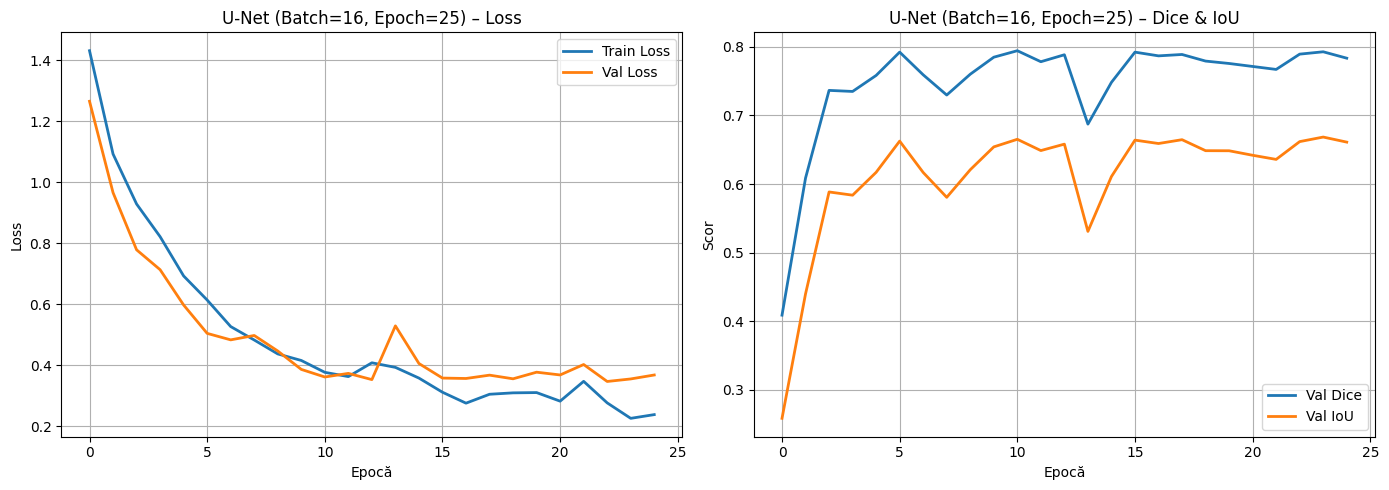

In [57]:
# Curbe de antrenare U-Net
plot_training_curves(history_unet, "U-Net (Batch=16, Epoch=25)")


In [58]:
# Evaluare U-Net pe TEST
results_unet = evaluate_model(model_unet, dl_test, DEVICE)
print("\n" + "="*50)
print("REZULTATE U-Net (Batch=16, Epoch=25) PE TEST:")
print("="*50)
for k, v in results_unet.items():
    print(f"  {k:<12}: {v:.4f}")



REZULTATE U-Net (Batch=16, Epoch=25) PE TEST:
  dice        : 0.7494
  iou         : 0.6033
  accuracy    : 0.9556
  precision   : 0.8337
  recall      : 0.6924


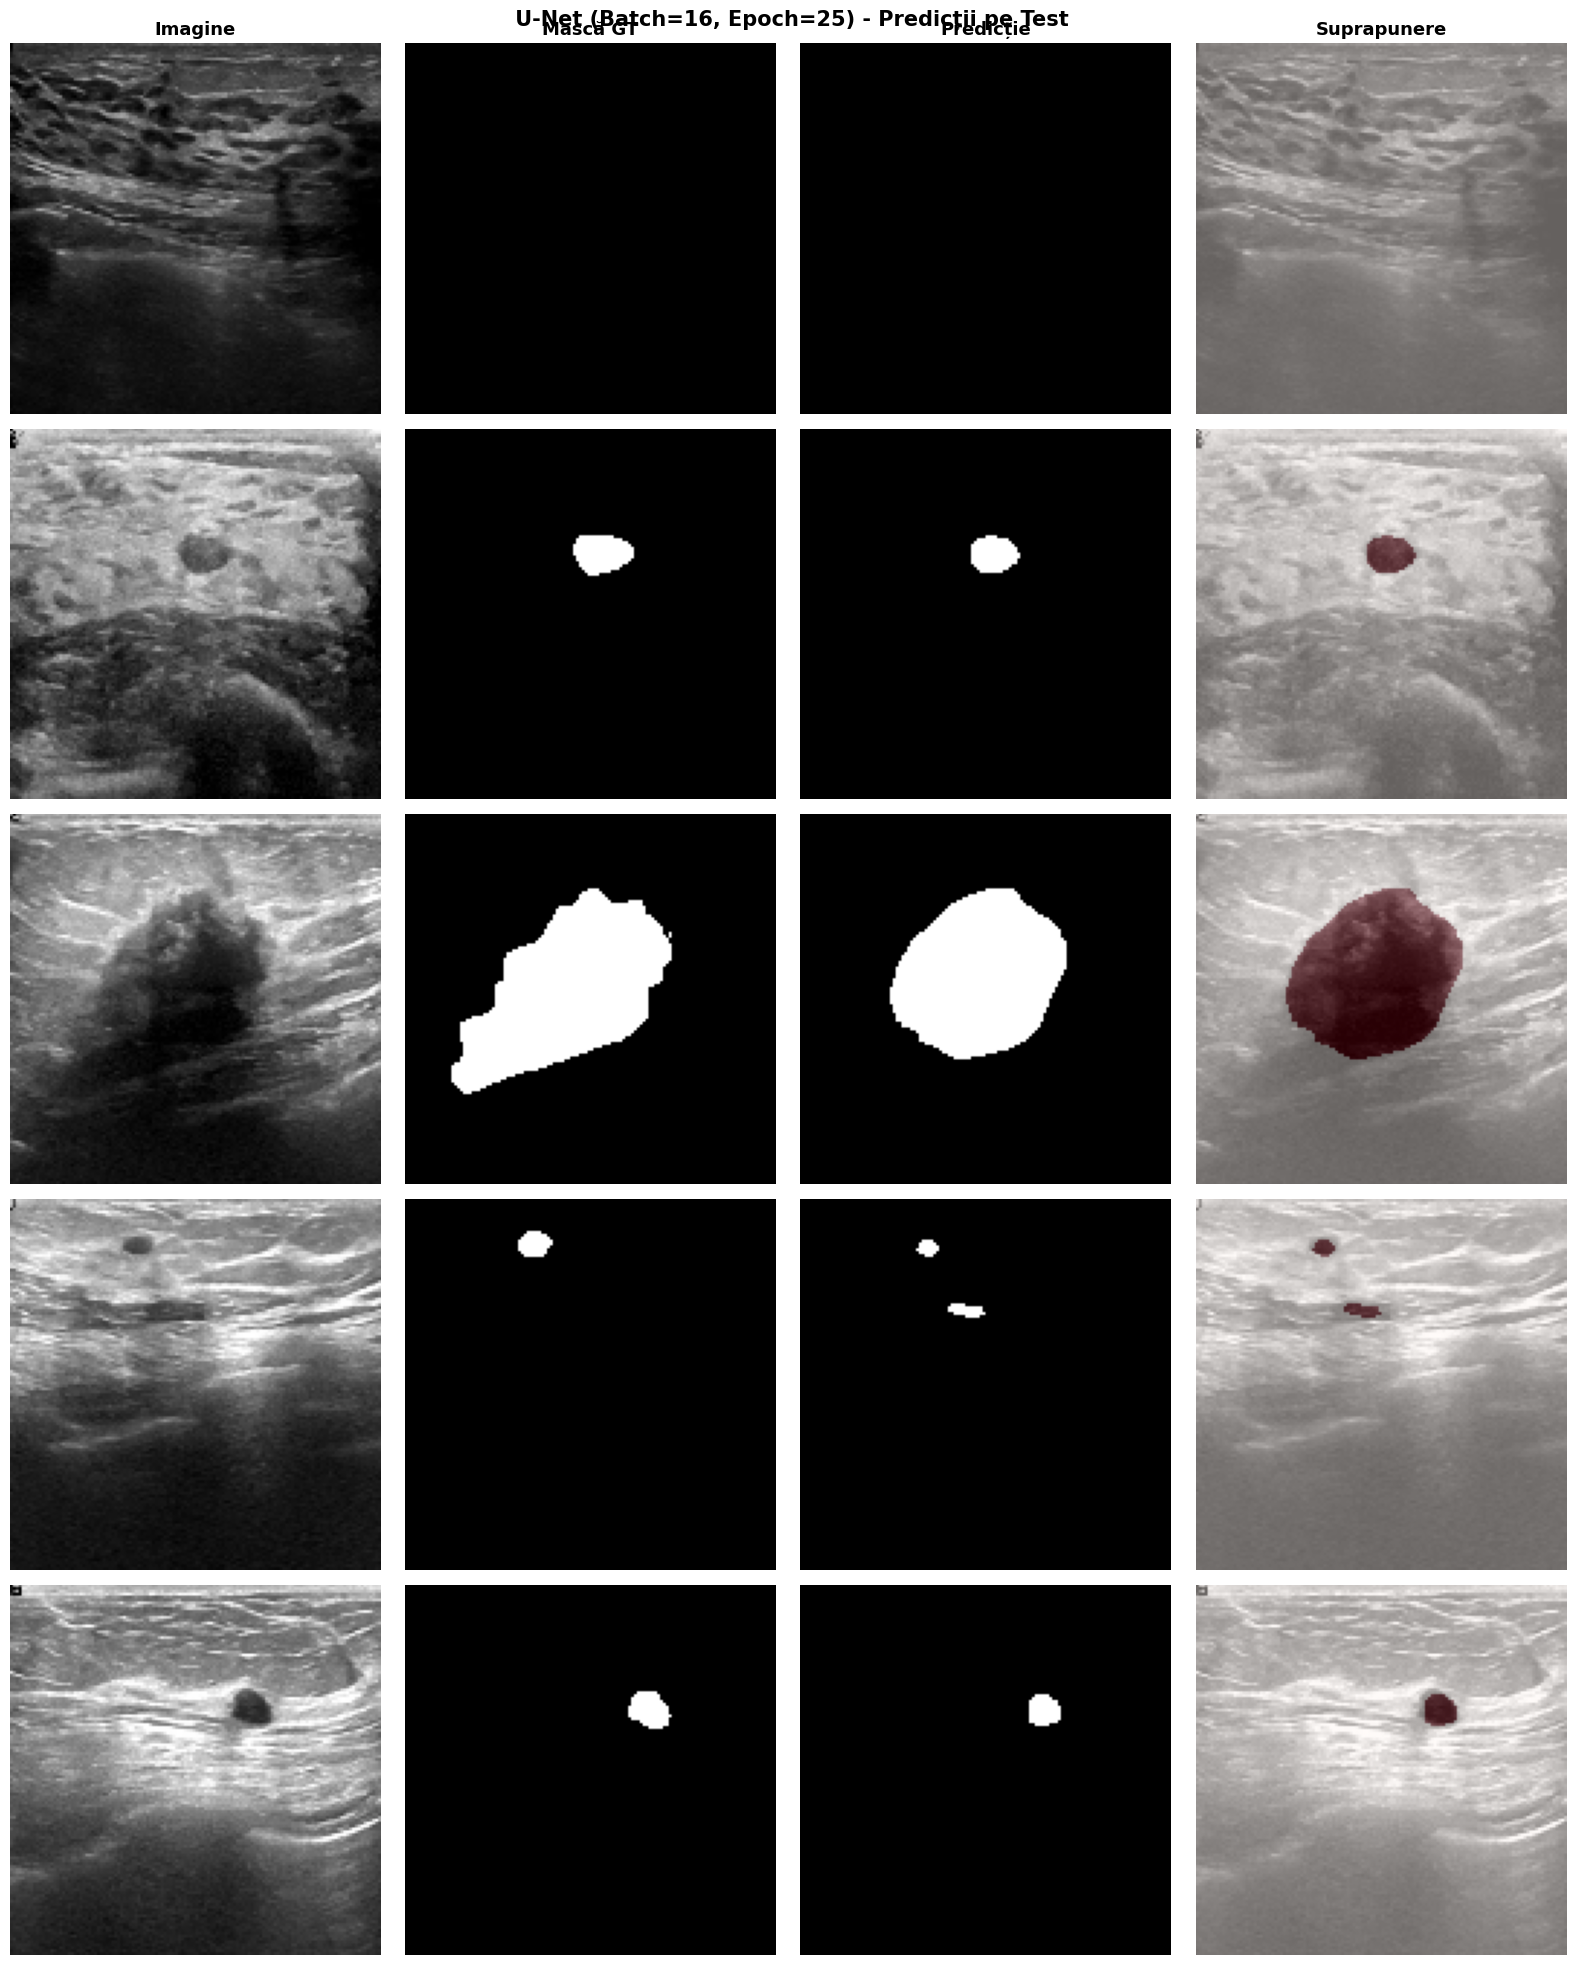

In [ ]:
# Vizualizare predictii U-Net
plot_predictions(model_unet, ds_test, DEVICE, n=5, title=" U-Net (Batch=16, Epoch=25) - Predicții pe Test")


### 1.2.3 Experimentul 2 – Segmentare cu U-Net++

U-Net++ (Nested U-Net) adaugă conexiuni dense între encoder și decoder, permițând captarea de features la multiple rezoluții.

In [ ]:

# Definire model U-Net++ (encoder ResNet34)

model_unetpp = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model_unetpp = model_unetpp.to(DEVICE)

total_params_pp = sum(p.numel() for p in model_unetpp.parameters())
trainable_params_pp = sum(p.numel() for p in model_unetpp.parameters() if p.requires_grad)
print(f"U-Net++ (ResNet34 encoder)")
print(f"  Parametri totali:     {total_params_pp:,}")
print(f"  Parametri antrenabili: {trainable_params_pp:,}")


U-Net++ (ResNet34 encoder)
  Parametri totali:     26,078,609
  Parametri antrenabili: 26,078,609


In [ ]:

# Antrenare U-Net++

model_unetpp, history_unetpp = train_model(
    model_unetpp, dl_train, dl_val, DEVICE,
    num_epochs=NUM_EPOCHS, lr=LR, model_name="U-Net++"
)


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


[U-Net++] Epoch 1/25 | Train Loss: 1.0867 | Val Loss: 0.8867 | Dice: 0.5994 | IoU: 0.4311 | LR: 0.000300
[U-Net++] Epoch 2/25 | Train Loss: 0.7578 | Val Loss: 0.6137 | Dice: 0.7691 | IoU: 0.6332 | LR: 0.000300
[U-Net++] Epoch 3/25 | Train Loss: 0.6180 | Val Loss: 0.6154 | Dice: 0.6976 | IoU: 0.5420 | LR: 0.000300
[U-Net++] Epoch 4/25 | Train Loss: 0.5707 | Val Loss: 0.5292 | Dice: 0.7175 | IoU: 0.5653 | LR: 0.000300
[U-Net++] Epoch 5/25 | Train Loss: 0.4714 | Val Loss: 0.4054 | Dice: 0.7903 | IoU: 0.6569 | LR: 0.000300
[U-Net++] Epoch 6/25 | Train Loss: 0.4174 | Val Loss: 0.4064 | Dice: 0.7681 | IoU: 0.6286 | LR: 0.000300
[U-Net++] Epoch 7/25 | Train Loss: 0.4272 | Val Loss: 0.3629 | Dice: 0.7901 | IoU: 0.6601 | LR: 0.000300
[U-Net++] Epoch 8/25 | Train Loss: 0.3538 | Val Loss: 0.3895 | Dice: 0.7698 | IoU: 0.6331 | LR: 0.000300
[U-Net++] Epoch 9/25 | Train Loss: 0.3256 | Val Loss: 0.3954 | Dice: 0.7645 | IoU: 0.6273 | LR: 0.000300
[U-Net++] Epoch 10/25 | Train Loss: 0.3176 | Val Loss: 

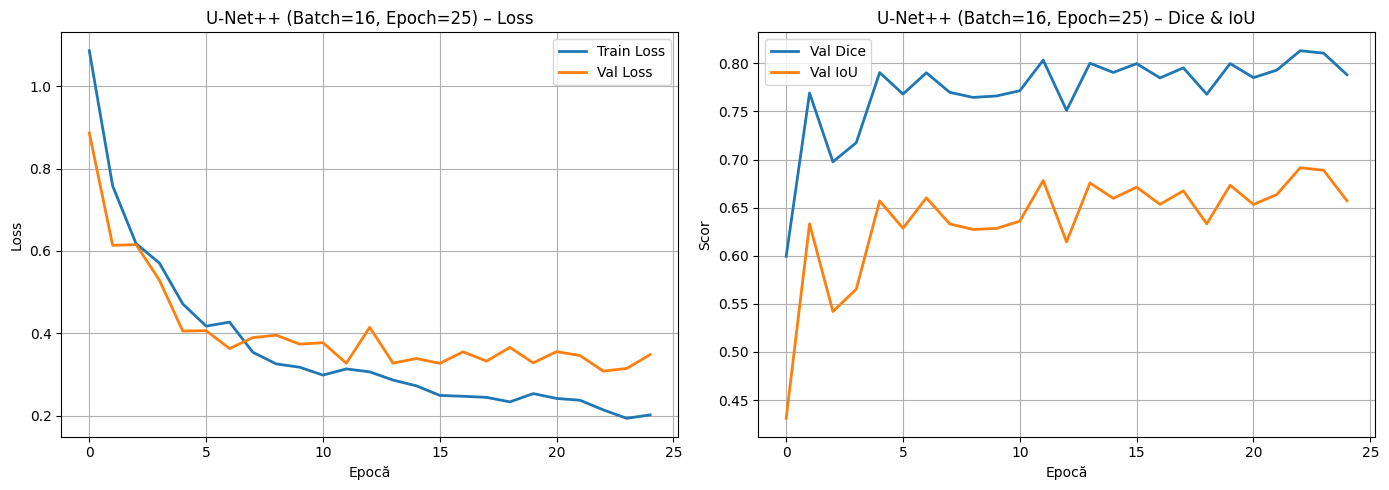

In [116]:
# Curbe de antrenare U-Net++
plot_training_curves(history_unetpp, "U-Net++ (Batch=16, Epoch=25)")


In [117]:
# Evaluare U-Net++ pe TEST
results_unetpp = evaluate_model(model_unetpp, dl_test, DEVICE)
print("\n" + "="*50)
print("REZULTATE U-Net++ (Batch=16, Epoch=25) PE TEST:")
print("="*50)
for k, v in results_unetpp.items():
    print(f"  {k:<12}: {v:.4f}")



REZULTATE U-Net++ (Batch=16, Epoch=25) PE TEST:
  dice        : 0.7655
  iou         : 0.6215
  accuracy    : 0.9575
  precision   : 0.8678
  recall      : 0.6953


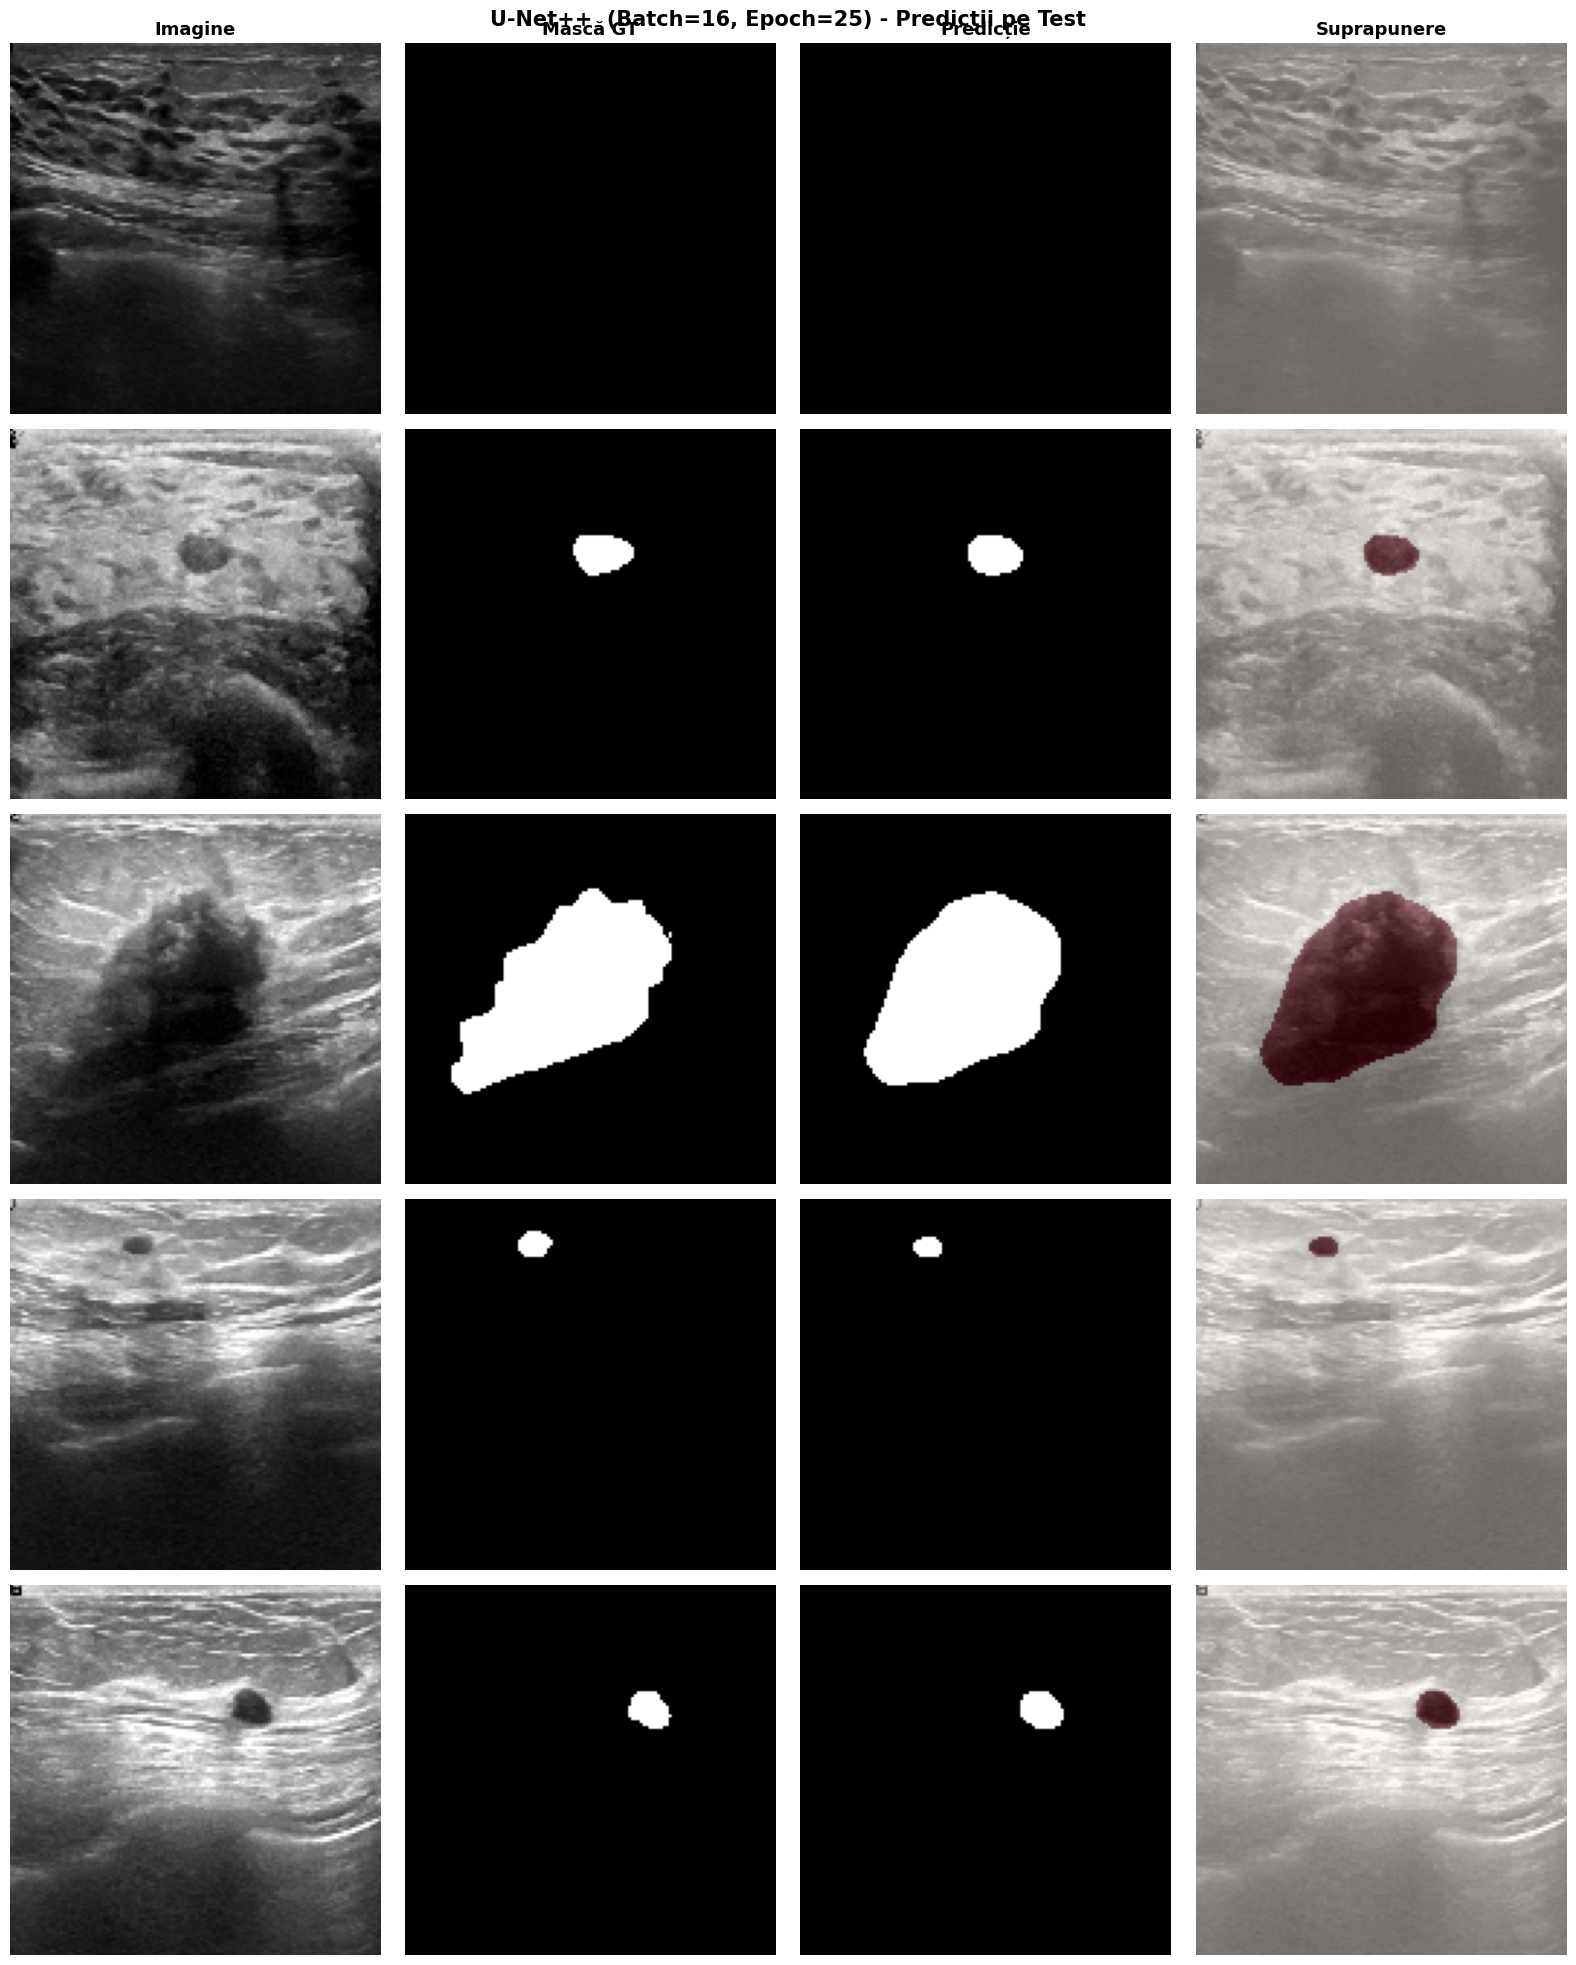

In [118]:
# Vizualizare predictii U-Net++
plot_predictions(model_unetpp, ds_test, DEVICE, n=5, title="U-Net++  (Batch=16, Epoch=25) - Predicții pe Test")


### 1.2.4 Comparație rezultate

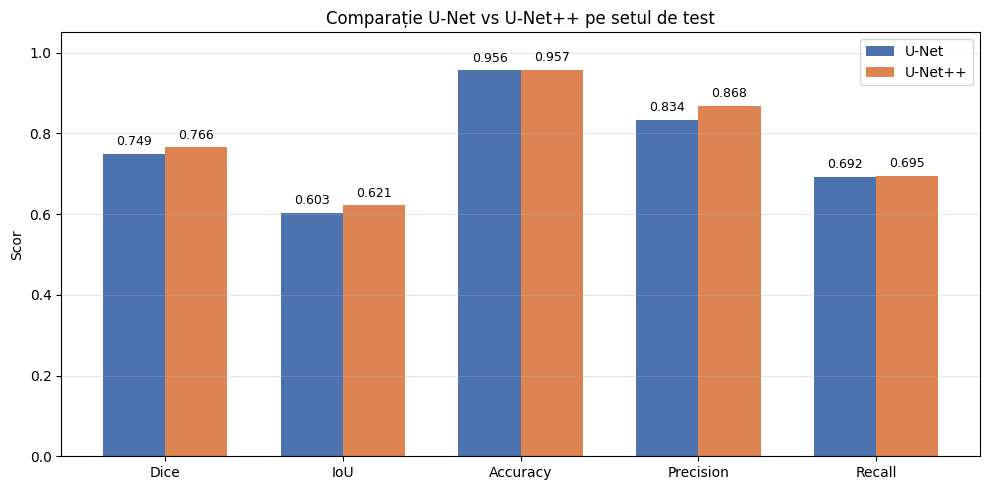

In [120]:

# Grafic comparativ (bar chart)

metrics_names = ["Dice", "IoU", "Accuracy", "Precision", "Recall"]
unet_vals = [results_unet[k] for k in ["dice", "iou", "accuracy", "precision", "recall"]]
unetpp_vals = [results_unetpp[k] for k in ["dice", "iou", "accuracy", "precision", "recall"]]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, unet_vals,  width, label="U-Net",   color="#4C72B0")
bars2 = ax.bar(x + width/2, unetpp_vals, width, label="U-Net++", color="#DD8452")

ax.set_ylabel("Scor")
ax.set_title("Comparație U-Net vs U-Net++ pe setul de test")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Valori deasupra barelor
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


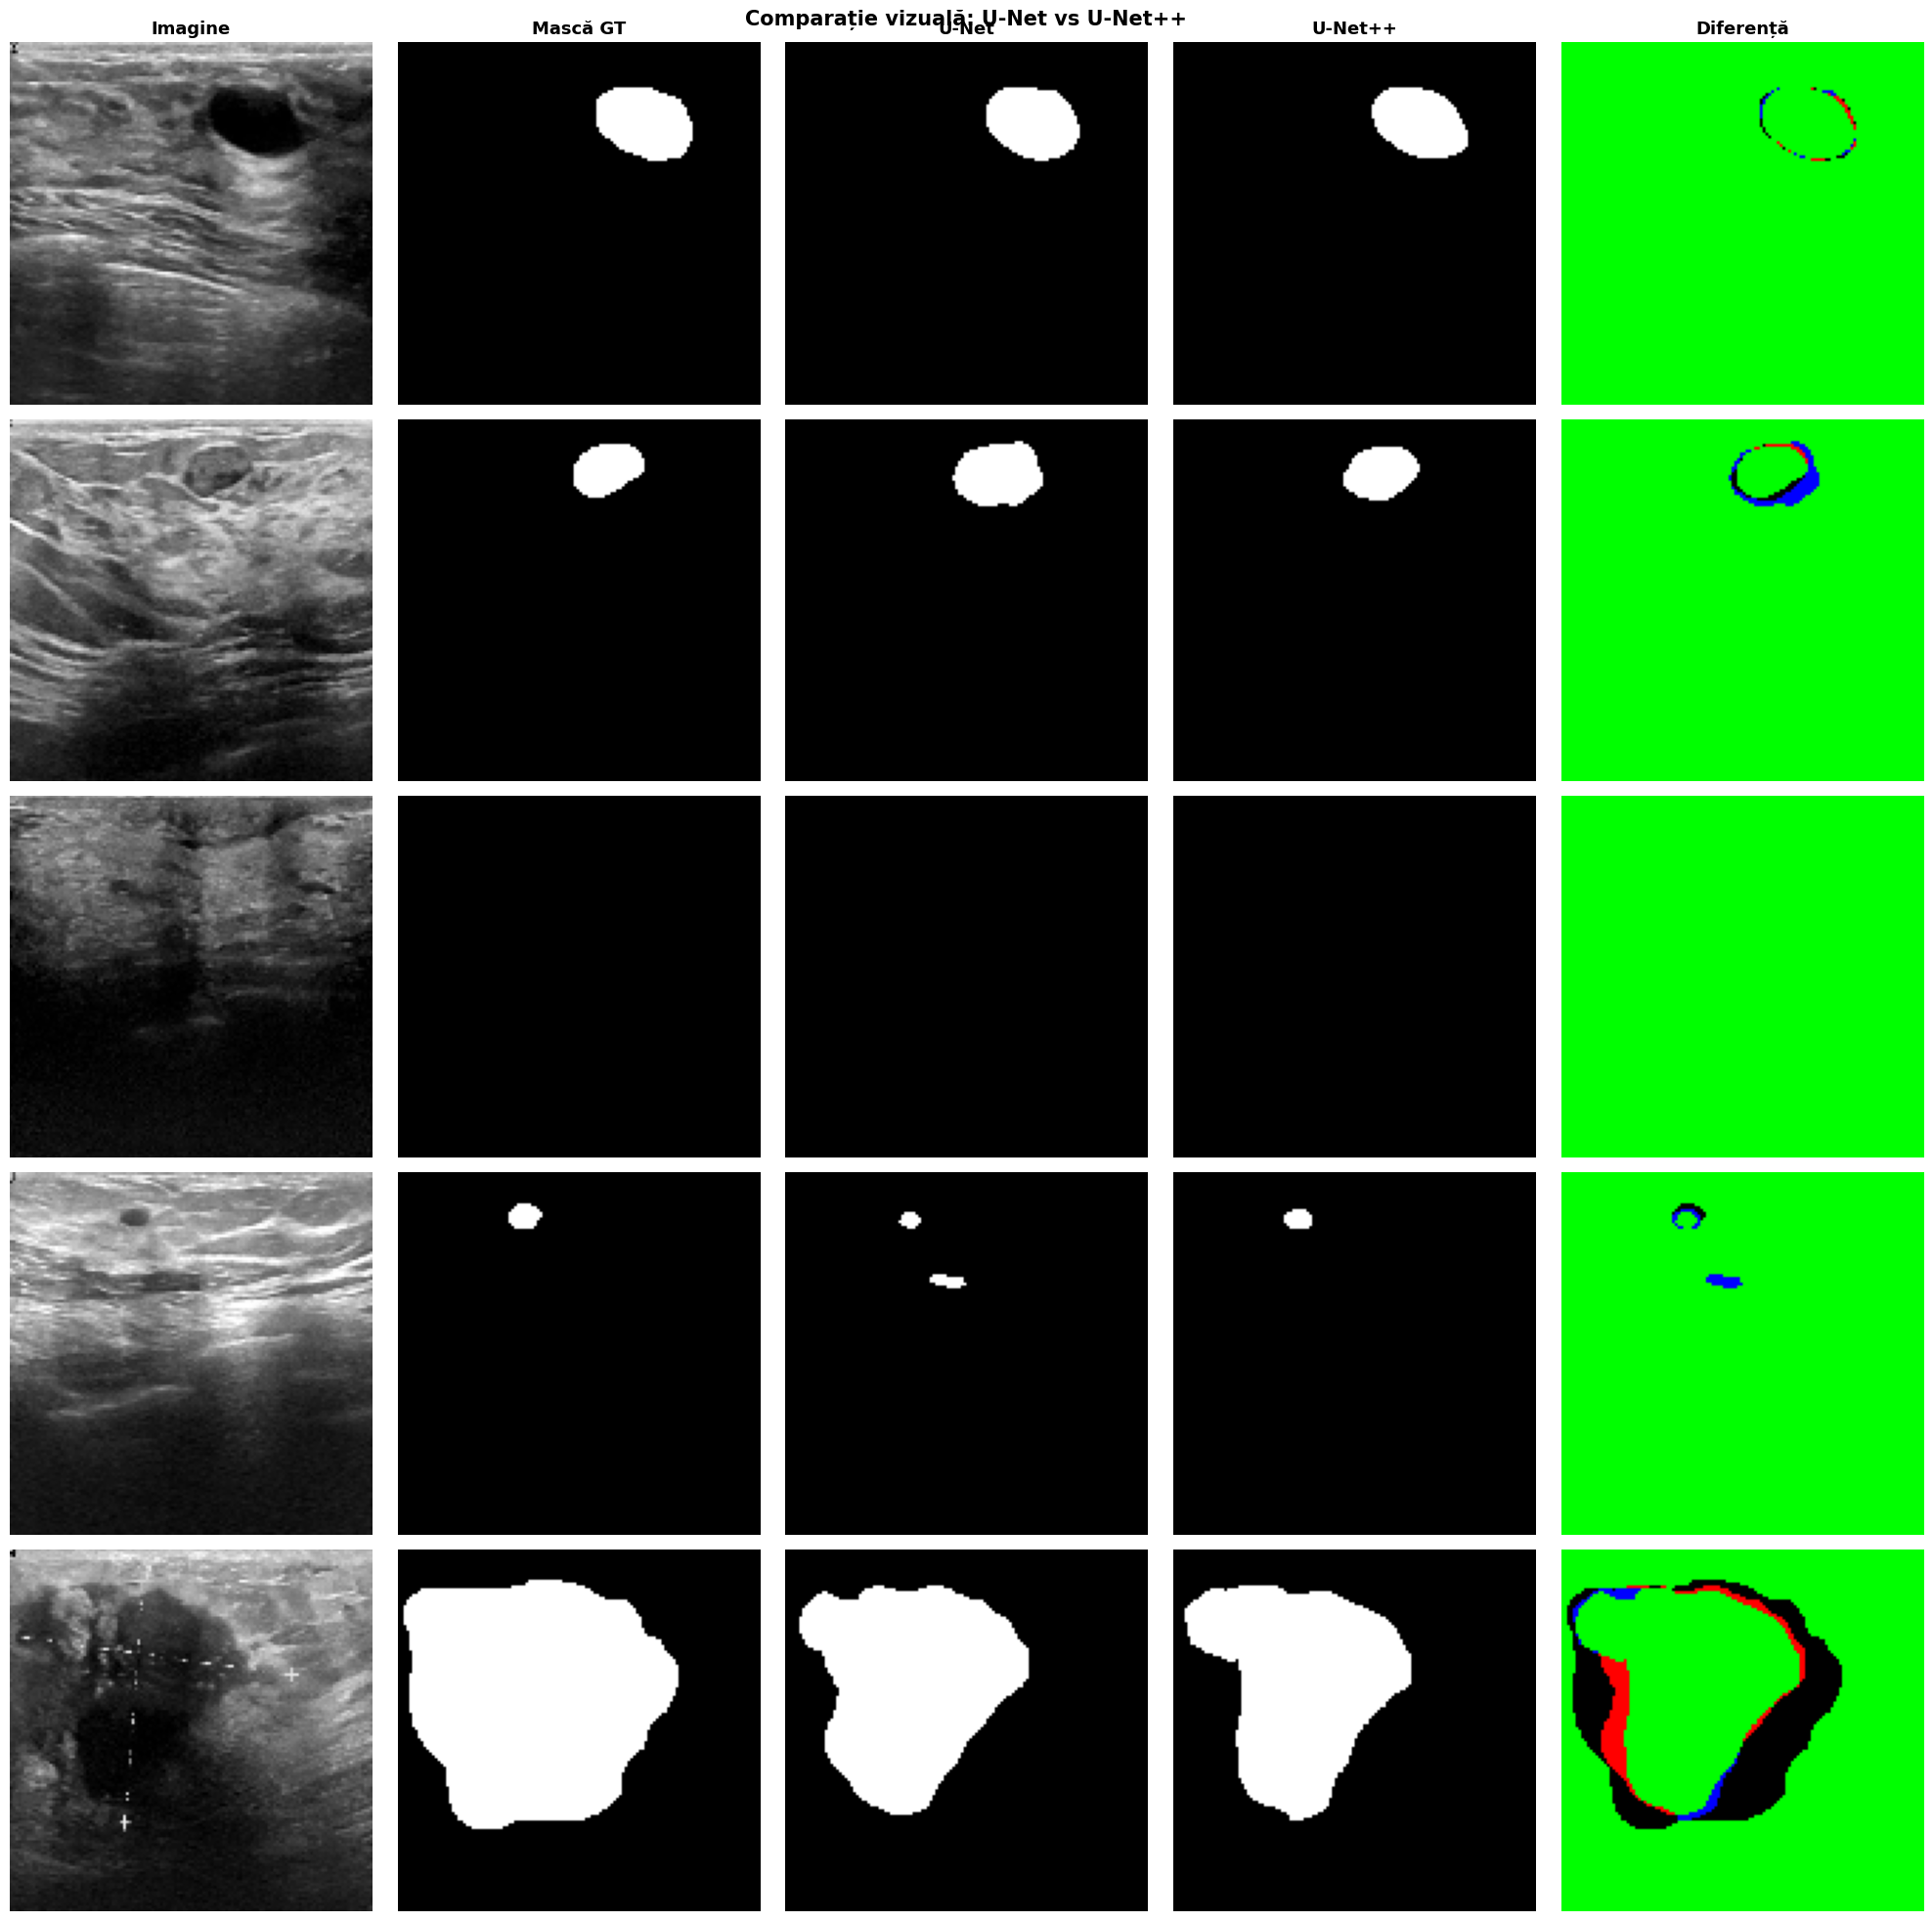

In [121]:

# Comparatie vizuala predictii: U-Net vs U-Net++ (aceleasi imagini)


def plot_comparison(model1, model2, dataset, device, n=5):
    model1.eval()
    model2.eval()

    fig, axes = plt.subplots(n, 5, figsize=(20, 4 * n))
    cols = ["Imagine", "Mască GT", "U-Net", "U-Net++", "Diferență"]
    for j, col in enumerate(cols):
        axes[0, j].set_title(col, fontsize=13, fontweight="bold")

    indices = random.sample(range(len(dataset)), n)
    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        inp = img.unsqueeze(0).to(device)

        with torch.no_grad():
            pred1 = torch.sigmoid(model1(inp)).cpu().squeeze().numpy()
            pred2 = torch.sigmoid(model2(inp)).cpu().squeeze().numpy()

        img_np = img.permute(1, 2, 0).numpy() * 0.5 + 0.5
        mask_np = mask.squeeze().numpy()
        pred1_bin = (pred1 > 0.5).astype(float)
        pred2_bin = (pred2 > 0.5).astype(float)

        # Diferenta: verde=ambele corecte, roșu=doar U-Net, albastru=doar U-Net++
        diff = np.zeros((*pred1_bin.shape, 3))
        diff[..., 1] = (pred1_bin == mask_np) & (pred2_bin == mask_np)  # verde
        diff[..., 0] = (pred1_bin != pred2_bin) & (pred1_bin == mask_np)  # rosu (U-Net mai bun)
        diff[..., 2] = (pred1_bin != pred2_bin) & (pred2_bin == mask_np)  # albastru (U-Net++ mai bun)

        axes[i, 0].imshow(img_np)
        axes[i, 1].imshow(mask_np, cmap="gray")
        axes[i, 2].imshow(pred1_bin, cmap="gray")
        axes[i, 3].imshow(pred2_bin, cmap="gray")
        axes[i, 4].imshow(diff)

    for ax in axes.flat:
        ax.axis("off")
    plt.suptitle("Comparație vizuală: U-Net vs U-Net++", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_comparison(model_unet, model_unetpp, ds_test, DEVICE, n=5)
